# PCIe end-to-end benchmark results

Analyze host codec plus CUDA PCIe transfer benchmarks. Choose a result directory, select the implementations to compare, and optionally save plots as vector PDFs for LaTeX.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from pernix_benchmark_tools.results import (
    PCIE_BENCHMARK_RE,
    load_benchmark_contexts,
    load_benchmark_results,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)


def find_repository_root() -> Path:
    for start in (Path.cwd().resolve(), Path.cwd().resolve().parent):
        for candidate in (start, *start.parents):
            if (candidate / "benchmark-tools" / "pyproject.toml").is_file():
                return candidate
    raise FileNotFoundError("Could not find the pernix-benchmark checkout")


REPOSITORY_ROOT = find_repository_root()
DEFAULT_RESULTS_ROOT = REPOSITORY_ROOT / "benchmark-results"
ALL_RESULTS = pd.DataFrame()
CONTEXTS = pd.DataFrame()
RESULT_DIR: Path | None = None

## Select results and implementations

Choose a discovered folder or type any other directory path into the folder field. Click **Load folder**, then select one or more implementations. Relative paths are resolved from the current working directory.

In [2]:
def discover_result_directories(root: Path) -> tuple[str, ...]:
    if not root.is_dir():
        return ()
    return tuple(
        str(path)
        for path in sorted(
            {
                file.parent.resolve()
                for file in root.rglob("benchmark_pcie_*_results.json")
            }
        )
    )


discovered_directories = discover_result_directories(DEFAULT_RESULTS_ROOT)
result_directory = widgets.Combobox(
    options=discovered_directories,
    value=discovered_directories[0] if discovered_directories else str(DEFAULT_RESULTS_ROOT),
    description="Results folder:",
    ensure_option=False,
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
refresh_folders = widgets.Button(description="Refresh folders", icon="refresh")
load_folder = widgets.Button(description="Load folder", button_style="primary", icon="folder-open")
implementation_selector = widgets.SelectMultiple(
    options=(),
    description="Implementations:",
    rows=7,
    layout=widgets.Layout(width="60%"),
    style={"description_width": "initial"},
)
select_all = widgets.Button(description="Select all")
clear_selection = widgets.Button(description="Clear")
save_pdfs = widgets.Checkbox(
    value=False,
    description="Save plots as vector PDF when plot cells run",
    indent=False,
    style={"description_width": "initial"},
)
pdf_directory = widgets.Text(
    value=str(DEFAULT_RESULTS_ROOT / "plots"),
    description="PDF folder:",
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
load_output = widgets.Output()


def refresh_directory_options(_button: widgets.Button) -> None:
    result_directory.options = discover_result_directories(DEFAULT_RESULTS_ROOT)


def load_result_folder(_button: widgets.Button) -> None:
    global ALL_RESULTS, CONTEXTS, RESULT_DIR
    with load_output:
        load_output.clear_output()
        try:
            directory = Path(result_directory.value).expanduser()
            if not directory.is_absolute():
                directory = (Path.cwd() / directory).resolve()
            else:
                directory = directory.resolve()
            loaded_results = load_benchmark_results(directory, family="pcie")
            loaded_contexts = load_benchmark_contexts(directory, family="pcie")
            loaded_results = loaded_results[
                loaded_results["benchmark_schema"] == "pcie_v1"
            ].copy()
            loaded_contexts = loaded_contexts[
                loaded_contexts["source_file"].str.startswith("benchmark_pcie_")
            ].copy()
            if loaded_results.empty:
                raise ValueError("No PCIe E2E benchmark results found in this folder")
        except Exception as error:
            display(Markdown(f"> **Could not load results:** `{error}`"))
            return

        required = [
            "implementation",
            "direction",
            "value_type",
            "memory_mode",
            "bit_width",
            "blocks",
        ]
        if loaded_results[required].isna().any().any():
            display(Markdown("> **Invalid results:** one or more benchmark dimensions are missing."))
            return

        ALL_RESULTS = loaded_results
        CONTEXTS = loaded_contexts
        RESULT_DIR = directory
        implementations = tuple(sorted(ALL_RESULTS["implementation"].unique()))
        implementation_selector.options = implementations
        implementation_selector.value = implementations
        pdf_directory.value = str(directory / "plots")
        display(Markdown(
            f"Loaded **{len(ALL_RESULTS):,} rows** from **{ALL_RESULTS['source_file'].nunique()} files** "
            f"in `{directory}`. Select implementations, then run the cells below."
        ))


refresh_folders.on_click(refresh_directory_options)
load_folder.on_click(load_result_folder)
select_all.on_click(lambda _button: setattr(
    implementation_selector, "value", tuple(implementation_selector.options)
))
clear_selection.on_click(lambda _button: setattr(implementation_selector, "value", ()))

display(widgets.VBox([
    result_directory,
    widgets.HBox([refresh_folders, load_folder]),
    implementation_selector,
    widgets.HBox([select_all, clear_selection]),
    save_pdfs,
    pdf_directory,
    load_output,
]))

In [7]:
def selected_results() -> pd.DataFrame:
    if ALL_RESULTS.empty:
        raise RuntimeError("Select a result folder and click 'Load folder' first")
    selected = list(implementation_selector.value)
    if not selected:
        raise ValueError("Select at least one implementation")
    return ALL_RESULTS[ALL_RESULTS["implementation"].isin(selected)].copy()



def selected_e2e_results() -> pd.DataFrame:
    results = selected_results()
    e2e = results[results["benchmark_schema"] == "pcie_v1"].copy()
    if e2e.empty:
        return e2e

    time_scales = {"ns": 1e-9, "us": 1e-6, "ms": 1e-3, "s": 1.0}
    e2e["transfer"] = e2e["transfer_direction"].map(
        {"h2d": "Host to device", "d2h": "Device to host"}
    )
    e2e["payload"] = e2e["payload_bytes"].map(
        lambda size: f"{int(size) / 2**20:g} MiB" if int(size) >= 2**20 else f"{int(size) / 2**10:g} KiB"
    )
    e2e["dma_gib_per_second"] = pd.to_numeric(
        e2e["dma_bytes_per_second"], errors="coerce"
    ) / 2**30
    e2e["e2e_seconds_per_iteration"] = (
        pd.to_numeric(e2e["real_time"], errors="coerce")
        * e2e["time_unit"].map(time_scales)
    )
    e2e["dma_seconds_per_iteration"] = (
        pd.to_numeric(e2e["dma_seconds"], errors="coerce")
        / pd.to_numeric(e2e["iterations"], errors="coerce")
    )
    e2e["dma_time_percent"] = (
        100 * e2e["dma_seconds_per_iteration"] / e2e["e2e_seconds_per_iteration"]
    ).clip(lower=0, upper=100)
    return e2e


def selected_contexts() -> pd.DataFrame:
    selected = list(implementation_selector.value)
    return CONTEXTS[CONTEXTS["implementation"].isin(selected)].copy()


def finish_figure(figure: plt.Figure, filename: str) -> None:
    if save_pdfs.value:
        output_directory = Path(pdf_directory.value).expanduser()
        if not output_directory.is_absolute():
            output_directory = (Path.cwd() / output_directory).resolve()
        output_directory.mkdir(parents=True, exist_ok=True)
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "-", filename).strip("-")
        destination = output_directory / f"{safe_name}.pdf"
        figure.savefig(destination, format="pdf", bbox_inches="tight")
        display(Markdown(f"Saved vector PDF: `{destination}`"))
    display(figure)
    plt.close(figure)


display(Markdown(
    "The implementation selector is live. After changing it, rerun the analysis cells "
    "you want to refresh. This notebook only uses PCIe E2E rows. Enable PDF "
    "export before running plot cells."
))

The implementation selector is live. After changing it, rerun the analysis cells you want to refresh. This notebook only uses PCIe E2E rows. Enable PDF export before running plot cells.

## Load and normalize

The anchored PCIe expression separates transfer direction, implementation, value type, bit width, and packed payload size. Names that do not match are rejected.

In [8]:
display(Markdown(f"**PCIe E2E regex:** `{PCIE_BENCHMARK_RE.pattern}`"))

results = selected_results()
assert (results["bytes_per_second"] > 0).all()

pd.DataFrame(
    {"value": [
        len(results),
        results["source_file"].nunique(),
        results["implementation"].nunique(),
        int(results["bit_width"].min()),
        int(results["bit_width"].max()),
        int(results["payload_bytes"].min()),
        int(results["payload_bytes"].max()),
    ]},
    index=[
        "rows",
        "result files",
        "selected implementations",
        "minimum bit width",
        "maximum bit width",
        "minimum packed payload bytes",
        "maximum packed payload bytes",
    ],
)

**PCIe E2E regex:** `^BM_pcie_(?P<transfer_direction>h2d|d2h)_(?P<implementation>[A-Za-z0-9]+?)(?P<value_type>f32|f64)_(?P<bit_width>\d+)/(?P<payload_bytes>\d+)$`

,value
rows,1152
result files,4
selected implementations,4
minimum bit width,1
maximum bit width,24
minimum packed payload bytes,4096
maximum packed payload bytes,67108864


## Run context and data quality

Host names, dates, frequencies, and load averages make cross-machine and cross-run differences visible. The optional `machinestate.json` is used when available.

In [9]:
if RESULT_DIR is None:
    raise RuntimeError("Load a result folder first")

machine_state_path = RESULT_DIR / "machinestate.json"
if machine_state_path.is_file():
    try:
        machine_state = json.loads(machine_state_path.read_text(encoding="utf-8"))
        cpu_name = machine_state.get("CpuInfo", {}).get("Name", "unknown CPU")
        display(Markdown(f"**Host CPU:** {cpu_name}"))
    except (OSError, json.JSONDecodeError) as error:
        display(Markdown(f"> Could not read `machinestate.json`: `{error}`"))
else:
    display(Markdown("No `machinestate.json` was found; benchmark context is shown below."))

contexts = selected_contexts()
context_columns = [
    column
    for column in ["implementation", "host_name", "date", "mhz_per_cpu", "load_avg", "library_version"]
    if column in contexts.columns
]
context_summary = contexts[context_columns].copy()
if "load_avg" in context_summary:
    load_values = context_summary.pop("load_avg").apply(
        lambda value: value if isinstance(value, list) and len(value) == 3 else [pd.NA] * 3
    )
    context_summary[["load_1m", "load_5m", "load_15m"]] = pd.DataFrame(
        load_values.tolist(), index=context_summary.index
    )
context_summary

**Host CPU:** AMD EPYC 9655 96-Core Processor

,implementation,host_name,date,mhz_per_cpu,library_version,load_1m,load_5m,load_15m
0,avx2,gpu1001,2026-07-26T23:51:38+02:00,2600,v1.9.4,1.14,1.14,1.44
1,avx512vbmi,gpu1001,2026-07-26T23:58:52+02:00,2600,v1.9.4,1.20,1.17,1.34
2,bmi2,gpu1001,2026-07-26T23:55:09+02:00,2600,v1.9.4,1.13,1.14,1.38
3,fallback,gpu1001,2026-07-26T23:47:54+02:00,2600,v1.9.4,1.16,1.13,1.52


## E2E coverage

Check that every selected implementation covers both transfer directions, both value types, all bit widths, and all packed payload sizes.

In [10]:
e2e = selected_e2e_results()
if e2e.empty:
    display(Markdown("> No PCIe E2E rows are present for the selected implementations."))
else:
    e2e_coverage = (
        e2e.groupby(
            ["implementation", "transfer", "value_type"],
            observed=True,
        )
        .agg(
            measurements=("name", "size"),
            bit_widths=("bit_width", "nunique"),
            payload_sizes=("payload_bytes", "nunique"),
        )
        .sort_index()
    )
    display(e2e_coverage)

measurements  bit_widths  \
implementation transfer       value_type                             
avx2           Device to host f32                   72          24   
                              f64                   72          24   
               Host to device f32                   72          24   
                              f64                   72          24   
avx512vbmi     Device to host f32                   72          24   
                              f64                   72          24   
               Host to device f32                   72          24   
                              f64                   72          24   
bmi2           Device to host f32                   72          24   
                              f64                   72          24   
               Host to device f32                   72          24   
                              f64                   72          24   
fallback       Device to host f32                   72          24   
                              f64                   72          24   
               Host to device f32                   72          24   
                              f64                   72          24   

                                          payload_sizes  
implementation transfer       value_type                 
avx2           Device to host f32                     3  
                              f64                     3  
               Host to device f32                     3  
                              f64                     3  
avx512vbmi     Device to host f32                     3  
                              f64                     3  
               Host to device f32                     3  
                              f64                     3  
bmi2           Device to host f32                     3  
                              f64                     3  
               Host to device f32                     3  
                              f64                     3  
fallback       Device to host f32                     3  
                              f64                     3  
               Host to device f32                     3  
                              f64                     3

## E2E useful throughput

Useful throughput counts the equivalent uncompressed bytes processed by the combined host codec and PCIe operation. Each column is a fixed packed transfer payload.

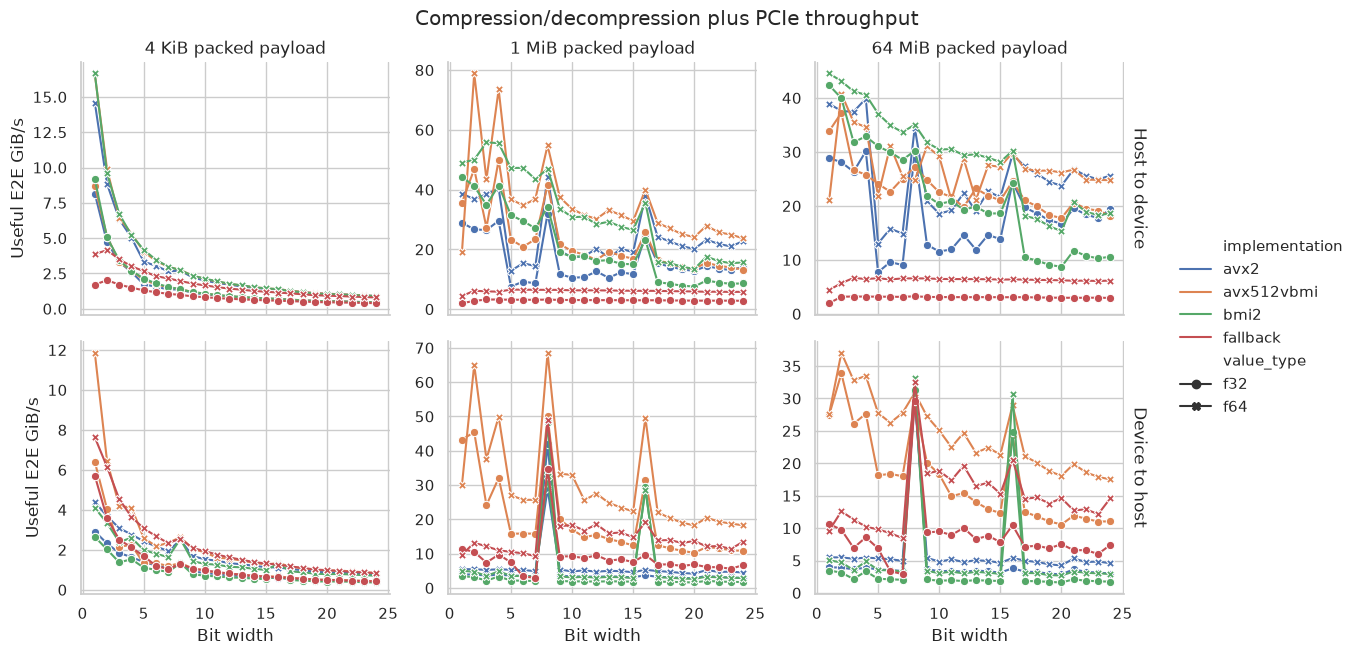

In [11]:
e2e = selected_e2e_results()
if e2e.empty:
    display(Markdown("> No PCIe E2E rows are present for the selected implementations."))
else:
    payload_order = (
        e2e[["payload_bytes", "payload"]]
        .drop_duplicates()
        .sort_values("payload_bytes")["payload"]
        .tolist()
    )
    grid = sns.relplot(
        data=e2e,
        x="bit_width",
        y="gib_per_second",
        hue="implementation",
        style="value_type",
        row="transfer",
        col="payload",
        col_order=payload_order,
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": False, "margin_titles": True},
        height=3.2,
        aspect=1.25,
    )
    grid.set_axis_labels("Bit width", "Useful E2E GiB/s")
    grid.set_titles(row_template="{row_name}", col_template="{col_name} packed payload")
    grid.figure.suptitle("Compression/decompression plus PCIe throughput", y=1.02)
    finish_figure(grid.figure, "e2e-useful-throughput")

## DMA-only PCIe bandwidth

CUDA-event timing isolates the packed transfer. Values below are medians across bit widths, which makes payload-size and direction effects easier to compare without conflating them with the host codec.

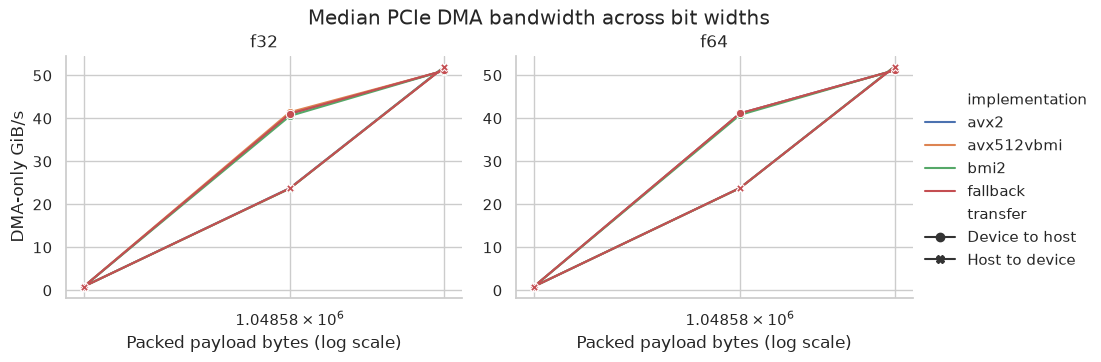

In [12]:
e2e = selected_e2e_results()
if e2e.empty:
    display(Markdown("> No PCIe E2E rows are present for the selected implementations."))
else:
    dma_summary = (
        e2e.groupby(
            ["implementation", "transfer", "value_type", "payload_bytes"],
            as_index=False,
            observed=True,
        )["dma_gib_per_second"]
        .median()
    )
    grid = sns.relplot(
        data=dma_summary,
        x="payload_bytes",
        y="dma_gib_per_second",
        hue="implementation",
        style="transfer",
        col="value_type",
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": False},
        height=3.5,
        aspect=1.35,
    )
    grid.set(xscale="log", xticks=sorted(dma_summary["payload_bytes"].unique()))
    grid.set_axis_labels("Packed payload bytes (log scale)", "DMA-only GiB/s")
    grid.set_titles(col_template="{col_name}")
    grid.figure.suptitle("Median PCIe DMA bandwidth across bit widths", y=1.02)
    finish_figure(grid.figure, "e2e-dma-bandwidth")

## E2E time composition

The DMA share divides CUDA-event transfer time per iteration by Google Benchmark wall time per iteration. The remaining percentage is primarily host compression or decompression plus synchronization and benchmark overhead.

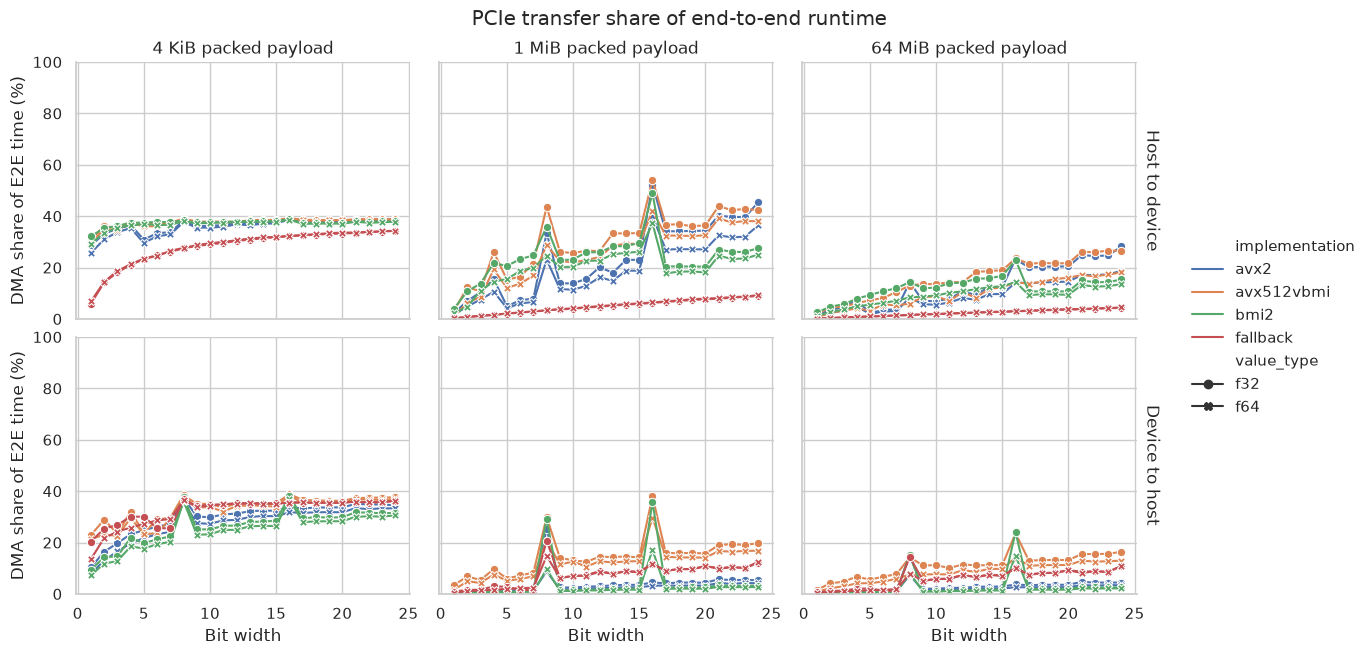

In [13]:
e2e = selected_e2e_results()
if e2e.empty:
    display(Markdown("> No PCIe E2E rows are present for the selected implementations."))
else:
    valid_timing = e2e.dropna(subset=["dma_time_percent"])
    if valid_timing.empty:
        raise ValueError("PCIe E2E rows contain no valid DMA timing values")
    payload_order = (
        valid_timing[["payload_bytes", "payload"]]
        .drop_duplicates()
        .sort_values("payload_bytes")["payload"]
        .tolist()
    )
    grid = sns.relplot(
        data=valid_timing,
        x="bit_width",
        y="dma_time_percent",
        hue="implementation",
        style="value_type",
        row="transfer",
        col="payload",
        col_order=payload_order,
        kind="line",
        markers=True,
        dashes=False,
        facet_kws={"sharey": True, "margin_titles": True},
        height=3.2,
        aspect=1.25,
    )
    grid.set(ylim=(0, 100))
    grid.set_axis_labels("Bit width", "DMA share of E2E time (%)")
    grid.set_titles(row_template="{row_name}", col_template="{col_name} packed payload")
    grid.figure.suptitle("PCIe transfer share of end-to-end runtime", y=1.02)
    finish_figure(grid.figure, "e2e-dma-time-share")

## E2E matched comparisons

Implementations are matched on transfer direction, value type, bit width, and packed payload. Winner counts only compare the selected implementations. When `fallback` is selected, the notebook also reports matched speedups over fallback.

### Winning selected implementation by matched E2E configuration

,transfer_direction,value_type,bit_width,payload_bytes,implementation,gib_per_second
577,d2h,f32,1,4096,avx512vbmi,6.398045
581,d2h,f32,1,1048576,avx512vbmi,43.274020
585,d2h,f32,1,67108864,avx512vbmi,27.451893
589,d2h,f32,2,4096,avx512vbmi,4.041201
593,d2h,f32,2,1048576,avx512vbmi,45.387212
...,...,...,...,...,...,...
557,h2d,f64,23,1048576,avx512vbmi,24.961190
560,h2d,f64,23,67108864,avx2,24.904134
564,h2d,f64,24,4096,avx2,0.905264
569,h2d,f64,24,1048576,avx512vbmi,23.655758


### E2E win count

,wins
implementation,
avx512vbmi,190
bmi2,61
fallback,22
avx2,15


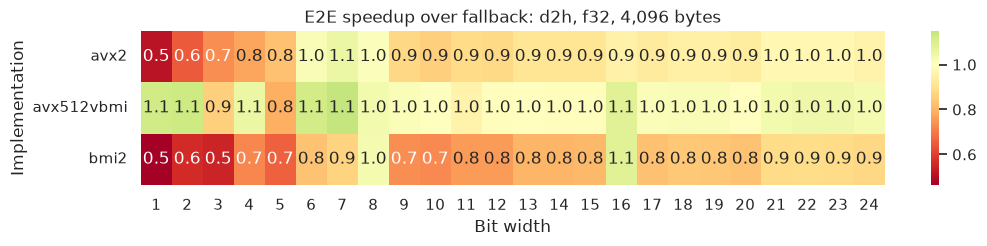

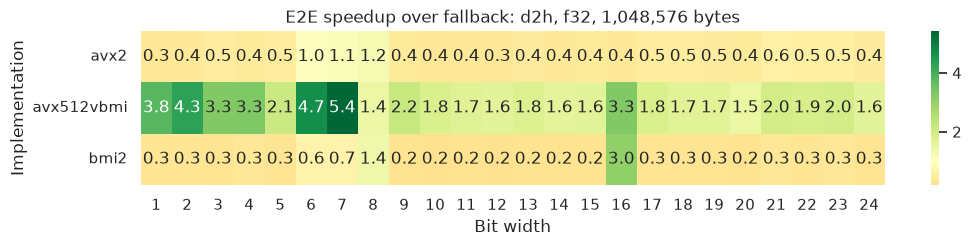

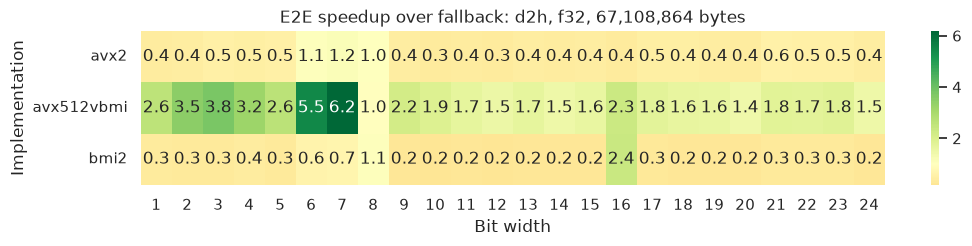

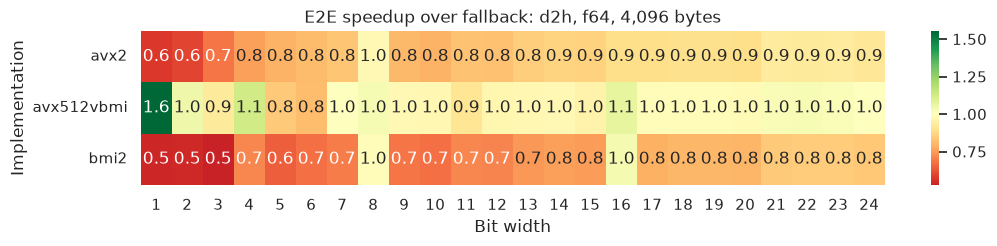

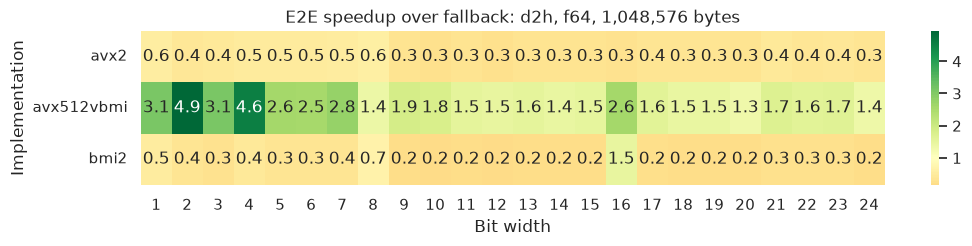

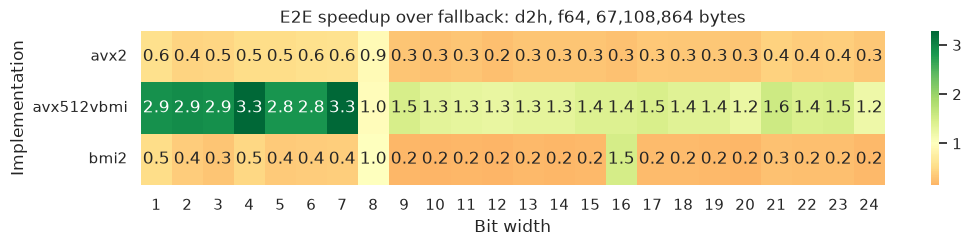

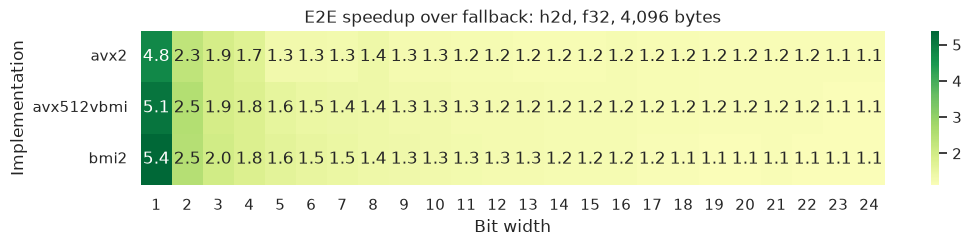

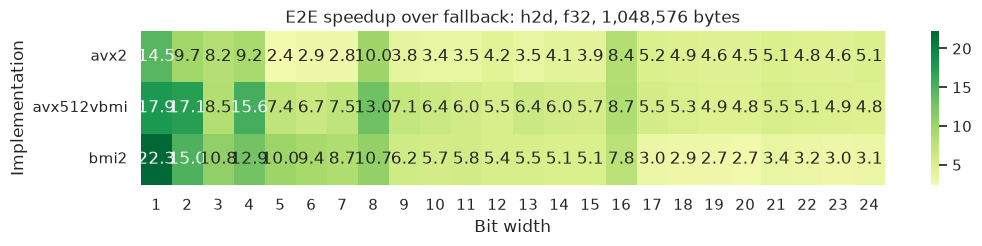

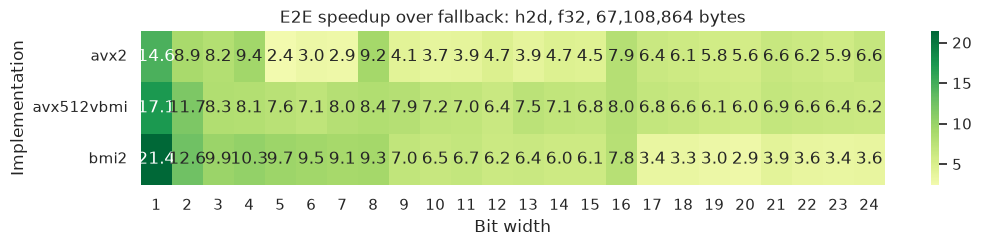

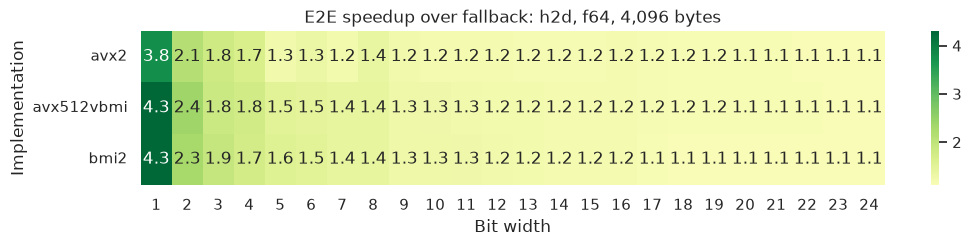

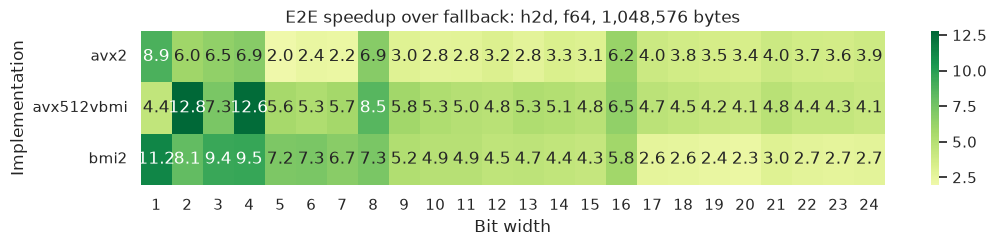

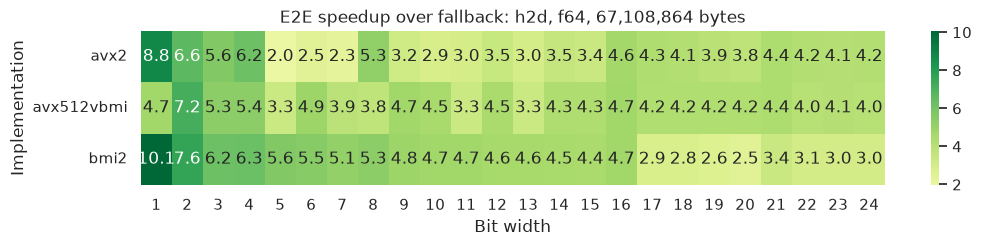

In [14]:
e2e = selected_e2e_results()
if e2e.empty:
    display(Markdown("> No PCIe E2E rows are present for the selected implementations."))
else:
    e2e_keys = ["transfer_direction", "value_type", "bit_width", "payload_bytes"]
    e2e_winners = e2e.loc[
        e2e.groupby(e2e_keys, observed=True)["bytes_per_second"].idxmax()
    ][e2e_keys + ["implementation", "gib_per_second"]].sort_values(e2e_keys)
    display(Markdown("### Winning selected implementation by matched E2E configuration"))
    display(e2e_winners)
    display(Markdown("### E2E win count"))
    display(e2e_winners["implementation"].value_counts().rename("wins").to_frame())

    if "fallback" not in set(e2e["implementation"]):
        display(Markdown("> Select `fallback` to calculate matched E2E speedups."))
    elif e2e["implementation"].nunique() < 2:
        display(Markdown("> Select at least one non-fallback implementation for E2E speedups."))
    else:
        fallback_e2e = (
            e2e[e2e["implementation"] == "fallback"][e2e_keys + ["bytes_per_second"]]
            .rename(columns={"bytes_per_second": "fallback_bytes_per_second"})
        )
        e2e_speedups = e2e.merge(
            fallback_e2e,
            on=e2e_keys,
            how="inner",
            validate="many_to_one",
        )
        e2e_speedups = e2e_speedups[e2e_speedups["implementation"] != "fallback"].copy()
        e2e_speedups["speedup_over_fallback"] = (
            e2e_speedups["bytes_per_second"] / e2e_speedups["fallback_bytes_per_second"]
        )
        for (transfer, value_type, payload_bytes), subset in e2e_speedups.groupby(
            ["transfer_direction", "value_type", "payload_bytes"], observed=True
        ):
            matrix = subset.pivot(
                index="implementation", columns="bit_width", values="speedup_over_fallback"
            )
            figure, axis = plt.subplots(figsize=(12, max(2.0, 0.65 * len(matrix))))
            sns.heatmap(matrix, cmap="RdYlGn", center=1.0, annot=True, fmt=".1f", ax=axis)
            axis.set_title(
                f"E2E speedup over fallback: {transfer}, {value_type}, {int(payload_bytes):,} bytes"
            )
            axis.set_xlabel("Bit width")
            axis.set_ylabel("Implementation")
            finish_figure(
                figure,
                f"e2e-speedup-{transfer}-{value_type}-{int(payload_bytes)}",
            )